# 06 · Convergence, caching, and cross-validation

Three questions decide whether you can trust an FDTD number:

1. **How fine a mesh do I need?** — `convergence.sweep` reruns a job while
   stepping the mesh and measures how much the S-matrix still moves.
2. **How do I avoid paying for the same run twice?** — `run_cached` hashes the
   whole job and reloads the stored result on a repeat.
3. **Is my *converged* answer even *correct*?** — the subtle one. A sweep tells
   you when an engine has stopped changing, not whether it stopped at the right
   value. The only way to know is to **cross-check a second engine**.

§1–2 run on free **beamz** (a straight waveguide). §3 tackles question 3 on a
hard device using **recorded** beamz + tidy3d results, so the whole notebook
reproduces for free — no cloud account or license needed.

In [1]:
import json
import tempfile
import time
from pathlib import Path

import gdsfactory as gf
import matplotlib.pyplot as plt
import numpy as np

from gds_fdtd.convergence import sweep
from gds_fdtd.layout.gdsfactory import from_gdsfactory
from gds_fdtd.lyprocessor import load_cell
from gds_fdtd.plotting import plot_component, plot_permittivity
from gds_fdtd.simprocessor import load_component_from_tech
from gds_fdtd.solvers import get_solver
from gds_fdtd.spec import SimulationSpec
from gds_fdtd.technology import Technology


def _find(rel: str) -> Path:
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / rel).exists():
            return base / rel
    raise FileNotFoundError(rel)


REC = _find("examples/06_convergence_and_caching/recorded")
tech = Technology.from_yaml(_find("examples/tech.yaml"))

## 1 · How fine a mesh? — a convergence sweep

A short straight waveguide, swept over three mesh densities on beamz.
`sweep` returns a `ConvergenceReport`; `max |ΔS|` is the worst-case change,
between successive meshes, of any S-parameter carrying real power
(`floor_db=-10` keeps the metric on the through path, not the deep numerical
reflection of a well-matched straight). A `cache_dir` means only genuinely new
points ever cost a run.

In [2]:
gf.gpdk.PDK.activate()
straight = from_gdsfactory(gf.components.straight(length=1.5), tech)
spec = SimulationSpec(wavelength_start=1.5, wavelength_end=1.6, wavelength_points=3,
                      z_min=-0.6, z_max=0.8)
cache = Path(tempfile.mkdtemp(prefix="gdsfdtd_conv_"))
mesh_values = [4, 6, 8]
TOL_DB = 0.25  # engineering tolerance — convergence is always relative to it

t0 = time.perf_counter()
report = sweep(get_solver("beamz"), straight, tech, spec,
               field="mesh", values=mesh_values, cache_dir=cache, floor_db=-10.0)
cold = time.perf_counter() - t0

for lo, hi, d in zip(mesh_values, mesh_values[1:], report.deltas_db):
    print(f"mesh {lo} → {hi}:  max |ΔS| = {d:.3f} dB")
rec = report.recommend(tol_db=TOL_DB)
print(f"\nrecommended mesh (tol {TOL_DB} dB): {rec}   ·   sweep wall time: {cold:.1f} s")

● Done: Raster cache hit (3d): 25986b9b7a7be653deb9ea6a34dcab2289effc66e6128271da9aa4bbd05b653a.npz | load=0.00s


● Done: Raster cache hit (3d): cb29a8da54e62e698f0312c5fdb2a016ca08b9ee421449c81bde6484a49ab33c.npz | load=0.01s


● Done: Raster cache hit (3d): 11be3c871fecf7df3d7f924955359cae6c4fc2b1c32fbe830f439d2d0d4e50ed.npz | load=0.04s


mesh 4 → 6:  max |ΔS| = 1.099 dB
mesh 6 → 8:  max |ΔS| = 0.219 dB

recommended mesh (tol 0.25 dB): 8   ·   sweep wall time: 142.8 s


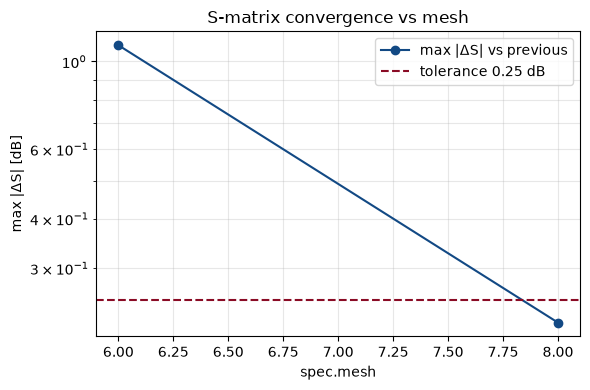

In [3]:
report.plot(tol_db=TOL_DB)
plt.show()

The change shrinks as the mesh refines — the coarsest grid is off by ~1 dB,
then it settles below the tolerance. `recommend` returns the coarsest mesh
that had already stopped moving: the one to use in production. The tolerance is
*your* call — a ±0.25 dB spec converges here; a strict 0.05 dB would demand a
finer sweep.

## 2 · Repeats are free — caching

Every point above was stored under a content hash. Re-running the **identical
sweep** recomputes nothing; change the geometry, technology, spec, or engine
version and only the genuinely new work reruns.

In [4]:
t0 = time.perf_counter()
again = sweep(get_solver("beamz"), straight, tech, spec,
              field="mesh", values=mesh_values, cache_dir=cache, floor_db=-10.0)
warm = time.perf_counter() - t0
print(f"cold sweep (new points): {cold:6.1f} s")
print(f"warm sweep (all cached): {warm:6.3f} s   →  {cold / max(warm, 1e-6):.0f}× faster")
print(f"identical result: {again.recommend(TOL_DB) == rec}")

cold sweep (new points):  142.8 s
warm sweep (all cached):  0.005 s   →  26395× faster
identical result: True


## 3 · Converged ≠ correct — cross-validate on a hard device

A sweep only tells you an engine *stopped changing*. On a benign device that's
enough; on a hard one it can plateau at the **wrong** value. Meet
**`sbend_dontfabme`** (from `examples/devices.gds`) — a deliberately *sharp*
S-bend that offsets the guide 0.5 µm in ~1 µm. A bend that tight strongly
**converts the fundamental mode into higher-order modes + radiation**, so its
true loss is large and it is a stress test for any solver.

First, the geometry the solvers build — device + cladding + the port
extensions that carry each port out through the domain edge:

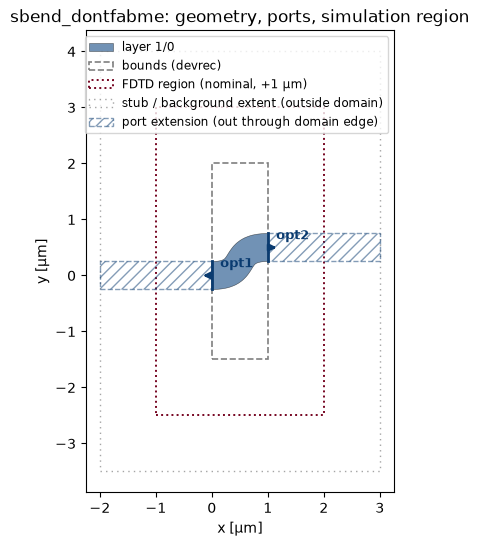

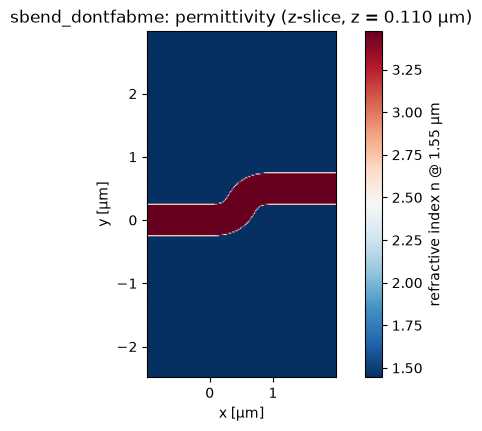

In [5]:
sbend_cell, _ = load_cell(str(_find("examples/devices.gds")), top_cell="sbend_dontfabme")
sbend = load_component_from_tech(cell=sbend_cell, tech=tech)
sbend.name = "sbend_dontfabme"
plot_component(sbend, spec=SimulationSpec())
plt.show()
plot_permittivity(sbend, axis="z", position=0.11, wavelength_um=1.55)  # top-down √ε at the Si core
plt.show()

### The convergence curves — beamz vs tidy3d

Single wavelength (1.55 µm), swept from low to high mesh on **both** engines
(recorded in `recorded/`; beamz on CPU, tidy3d on the cloud, which reaches high
mesh cheaply). S21 on the left axis, S11 on the right.

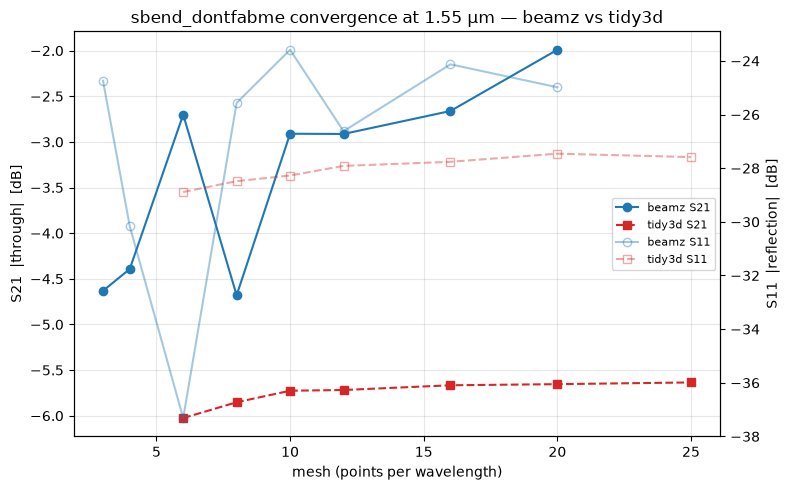

In [6]:
beamz_c = json.loads((REC / "sbend_beamz_convergence.json").read_text())["mesh"]
tidy3d_c = json.loads((REC / "sbend_tidy3d_convergence.json").read_text())["mesh"]

fig, axL = plt.subplots(figsize=(8, 5))
axR = axL.twinx()
bm = sorted(int(m) for m in beamz_c)
tm = sorted(int(m) for m in tidy3d_c)
axL.plot(bm, [beamz_c[str(m)]["s21_db"] for m in bm], "o-", color="tab:blue", label="beamz S21")
axL.plot(tm, [tidy3d_c[str(m)]["s21_db"] for m in tm], "s--", color="tab:red", label="tidy3d S21")
axR.plot(bm, [beamz_c[str(m)]["s11_db"] for m in bm], "o-", color="tab:blue", alpha=0.4,
         markerfacecolor="none", label="beamz S11")
axR.plot(tm, [tidy3d_c[str(m)]["s11_db"] for m in tm], "s--", color="tab:red", alpha=0.4,
         markerfacecolor="none", label="tidy3d S11")
axL.set_xlabel("mesh (points per wavelength)")
axL.set_ylabel("S21  |through|  [dB]")
axR.set_ylabel("S11  |reflection|  [dB]")
axL.set_title("sbend_dontfabme convergence at 1.55 µm — beamz vs tidy3d")
axL.grid(True, alpha=0.3)
_ln = axL.get_lines() + axR.get_lines()
axL.legend(_ln, [ln.get_label() for ln in _ln], loc="center right", fontsize=8)
fig.tight_layout()
plt.show()

**tidy3d converges cleanly and monotonically** to S21 ≈ −5.6 dB and holds it.
**beamz never converges** — its S21 *wanders* between about −4.7 and −2.0 dB
and shows no trend toward tidy3d; its finest point here (mesh 20) is −1.99 dB,
its *farthest* from the reference. When refining the mesh moves the answer
around the *wrong* value instead of settling on the right one, the error is in
the **model**, not the resolution — no mesh will fix it.

### First rule out the obvious — is it the same launched mode?

A wider field could just mean a different injected mode. It doesn't: both mode
solvers find the **fundamental TE0** of the 0.5 µm guide at nearly identical
effective index, and their lateral profiles sit almost on top of each other.
So the waveguide and the launched mode are the same — whatever differs
downstream is *not* a wider guide.

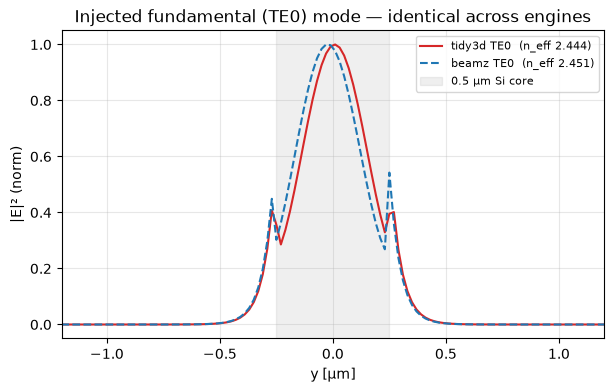

In [7]:
md = np.load(REC / "sbend_injected_modes.npz")
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(md["y_tidy3d"], md["e2_tidy3d"], color="tab:red",
        label=f"tidy3d TE0  (n_eff {float(md['neff_tidy3d']):.3f})")
ax.plot(md["y_beamz"], md["e2_beamz"], "--", color="tab:blue",
        label=f"beamz TE0  (n_eff {float(md['neff_beamz']):.3f})")
ax.axvspan(-0.25, 0.25, alpha=0.12, color="gray", label="0.5 µm Si core")
ax.set_xlim(-1.2, 1.2)
ax.set_xlabel("y [µm]")
ax.set_ylabel("|E|² (norm)")
ax.set_title("Injected fundamental (TE0) mode — identical across engines")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.show()

### Now the field through the bend — linear *and* log

Same launched mode, so watch how the field **evolves**. Top row is a **linear**
scale (only the strong, guided field shows — faint radiation can't inflate it);
bottom is **log (dB)** (the radiation becomes visible). Each panel is normalized
to its own peak; cyan rings mark the two ports.

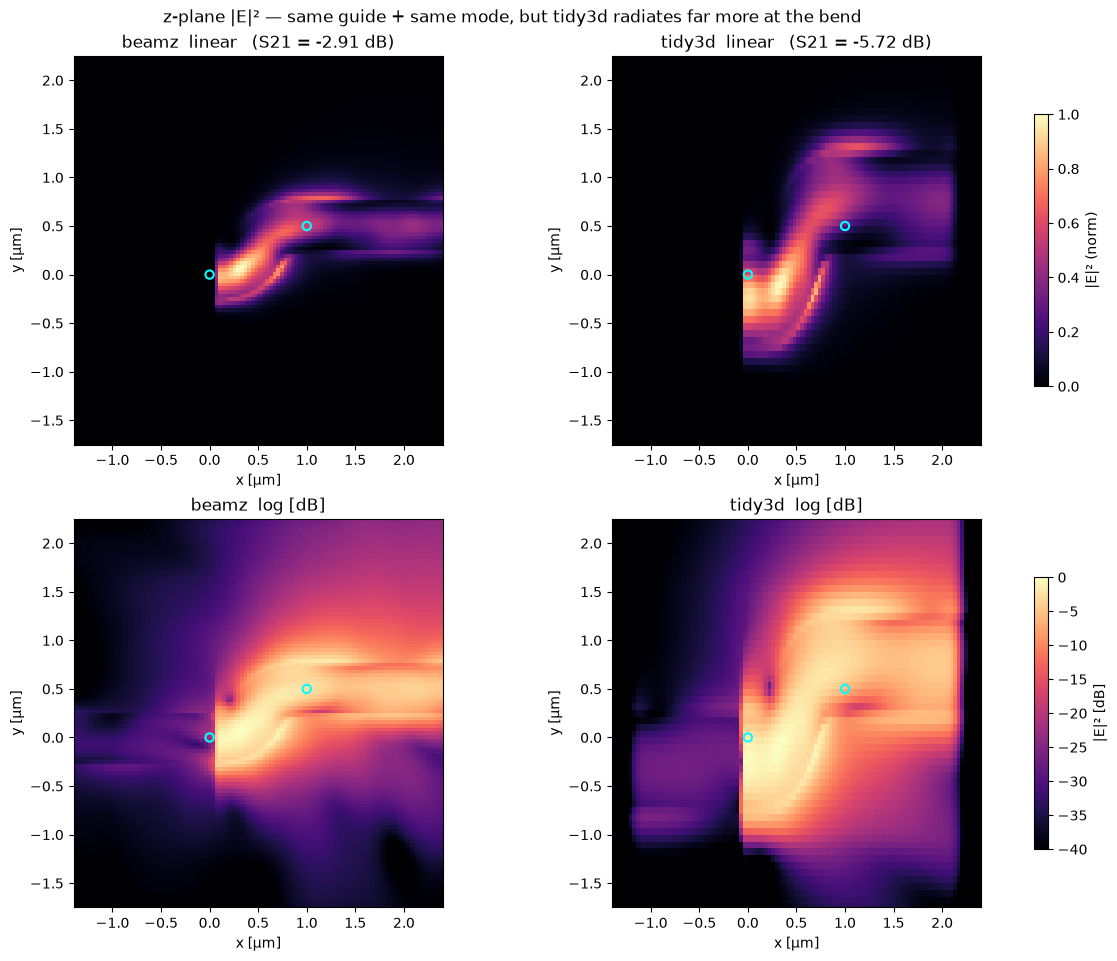

In [8]:
bz = np.load(REC / "sbend_beamz_field.npz")
t3 = np.load(REC / "sbend_tidy3d_field.npz")
bw, bh = float(bz["width_um"]), float(bz["height_um"])
cx, cy = sbend.bounds.x_center, sbend.bounds.y_center  # beamz's 0-based frame -> device coords
b_ext = [cx - bw / 2, cx + bw / 2, cy - bh / 2, cy + bh / 2]
t_ext = [t3["x"].min(), t3["x"].max(), t3["y"].min(), t3["y"].max()]
panels = [("beamz", bz["E2"], b_ext, float(bz["s21"])),
          ("tidy3d", t3["E2"].T, t_ext, float(t3["s21"]))]

fig, ax = plt.subplots(2, 2, figsize=(12, 9.5), constrained_layout=True)
for col, (name, e2, ext, s21) in enumerate(panels):
    en = e2 / e2.max()
    im_lin = ax[0, col].imshow(en, extent=ext, origin="lower", aspect="equal",
                               cmap="magma", vmin=0, vmax=1)
    ax[0, col].set_title(f"{name}  linear   (S21 = {s21:+.2f} dB)")
    im_log = ax[1, col].imshow(10 * np.log10(np.clip(en, 1e-4, 1)), extent=ext, origin="lower",
                               aspect="equal", cmap="magma", vmin=-40, vmax=0)
    ax[1, col].set_title(f"{name}  log [dB]")
    for r in (0, 1):
        ax[r, col].scatter([0, 1], [0, 0.5], s=36, edgecolor="cyan", facecolor="none", lw=1.5)
        ax[r, col].set_xlim(cx - 1.9, cx + 1.9)
        ax[r, col].set_ylim(cy - 2, cy + 2)
        ax[r, col].set_xlabel("x [µm]")
        ax[r, col].set_ylabel("y [µm]")
fig.colorbar(im_lin, ax=ax[0, :], label="|E|² (norm)", shrink=0.7)
fig.colorbar(im_log, ax=ax[1, :], label="|E|² [dB]", shrink=0.7)
fig.suptitle("z-plane |E|² — same guide + same mode, but tidy3d radiates far more at the bend")
plt.show()

Even on the **linear** scale — where faint radiation can't bloom — tidy3d's
field visibly **fans out** at the bend (up to y ≈ 1.3), while beamz's hugs the
guide. The guided *core* is the same width in both (~0.5 µm, matching the mode
above); the extra width in tidy3d is the higher-order-mode + radiation the sharp
bend throws off — power that leaves the fundamental. **beamz keeps the field
artificially confined** (its v1 single-mode normalization under-produces that
conversion), which is exactly why it reports ~3 dB less loss. Same waveguide,
same launched mode — the difference is how much bend radiation each engine
captures.

### The verdict — converged ≠ correct

As an energy budget at 1.55 µm: tidy3d (S21 −5.6, S11 −27.6 dB) puts a stable
~**72 %** of the input into radiation/mode-conversion; beamz's estimate swings
with mesh (roughly 35–55 % lost) and never reaches it. The setup is correct on
**both** — identical geometry and launched mode (verify by re-running §1's
engine on `sbend` yourself). The gap is a **model**
limit: tidy3d does a proper multi-mode modal decomposition at the ports, while
beamz's v1 adapter uses single-mode, per-direction normalization that
under-counts mode conversion. beamz is excellent for straights and *adiabatic*
transitions (it matches the `10_cookbook` Si→SiN escalator within ~0.1 dB) —
but a sharp, radiative bend is outside its comfort zone.

**Lesson:** a convergence sweep is *necessary but not sufficient*. For anything
strongly multi-mode or radiative, cross-validate against a second engine before
you trust the number.

## Recap & next

`sweep` finds the coarsest converged mesh; `run_cached` makes repeats free; and
convergence alone doesn't guarantee correctness — cross-check a second engine on
hard devices. Next: **`07_choosing_an_engine`** — the same job on beamz, tidy3d,
and Lumerical, and how they line up.